# ALLaM-7B — Fine-Tuned Arabic Document Sensitivity Classifier
Fine-tuning **ALLaM-7B-Instruct** with QLoRA on Arabic documents, then evaluating on a held-out test set.
Classification follows **NDMO/SDAIA** sensitivity levels: عام · مقيد · سري · سري للغاية

## 0. Setup

In [ ]:
# Install all required libraries for QLoRA fine-tuning
!pip install -U bitsandbytes>=0.46.1 accelerate peft trl transformers datasets


In [ ]:
# ── Imports ──────────────────────────────────────────────
import os, gc, torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from datasets import Dataset
from google.colab import drive, userdata
from huggingface_hub import login
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig


✅ تم استدعاء جميع المكتبات بنجاح!


In [ ]:
# ── Mount Google Drive & Authenticate ───────────────────
drive.mount('/content/drive')
login(token=userdata.get('HF_TOKEN'))


Mounted at /content/drive
جاري قراءة ملف البيانات...

✅ تم تحميل البيانات بنجاح!
عدد الوثائق للتدريب: 40000
الأعمدة المتوفرة في الملف: ['content', 'sensitivity_level']


,content,sensitivity_level
0,صياغة سيناريوهات تشغيل موجه إلى الجهات ذات الع...,سري للغاية
1,جرى تدقيق نقاط التحسين مع توثيق النتائج وفق ال...,سري للغاية
2,مراجعة أسباب التباين موجه إلى المعنيين بصيغة ر...,سري


In [ ]:
# ── Paths & Global Constants ─────────────────────────────
MODEL_ID      = "humain-ai/ALLaM-7B-Instruct-preview"
DATASET_PATH  = "/content/drive/MyDrive/Project/synthetic_sensitivity_dataset_v3.csv"
OUTPUT_DIR    = "/content/drive/MyDrive/Project/allam_ndmo_lora"
SAVE_FILE     = "/content/drive/MyDrive/Project/allam_final_expert_results.csv"
VALID_CLASSES = ["عام", "مقيد", "سري", "سري للغاية"]
ENGLISH_LABELS= ["Public", "Restricted", "Secret", "Top Secret"]

os.makedirs(OUTPUT_DIR, exist_ok=True)


## 1. Data Preparation

In [ ]:
# Load dataset and verify required columns
print("Loading dataset...")
train_data_df = pd.read_csv(DATASET_PATH)

print(f"Total documents: {len(train_data_df)}")
print(f"Columns: {train_data_df.columns.tolist()}")
print(f"Class distribution:\n{train_data_df['sensitivity_level'].value_counts()}")
display(train_data_df.head(3))


Mounted at /content/drive
جاري قراءة ملف البيانات...

✅ تم تحميل البيانات بنجاح!
عدد الوثائق للتدريب: 40000
الأعمدة المتوفرة في الملف: ['content', 'sensitivity_level']


,content,sensitivity_level
0,صياغة سيناريوهات تشغيل موجه إلى الجهات ذات الع...,سري للغاية
1,جرى تدقيق نقاط التحسين مع توثيق النتائج وفق ال...,سري للغاية
2,مراجعة أسباب التباين موجه إلى المعنيين بصيغة ر...,سري


In [ ]:
# Format each row into ALLaM chat-template prompt+answer format
SYSTEM_PROMPT = (
    "أنت خبير في تصنيف الوثائق الإدارية السعودية حسب ضوابط NDMO. "
    "صنف الوثيقة التالية إلى فئة واحدة فقط: (عام، مقيد، سري، سري للغاية). "
    "تذكر: أي بيانات تتعلق بالرعاية الصحية تُصنف دائماً كـ 'مقيد'."
)

# Load tokenizer first — needed for apply_chat_template
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"  # Right padding is better for training

def create_training_prompt(row):
    messages = [
        {"role": "system",    "content": SYSTEM_PROMPT},
        {"role": "user",      "content": f"الوثيقة: {row['content']}"},
        {"role": "assistant", "content": row['sensitivity_level']}
    ]
    return {"text": tokenizer.apply_chat_template(messages, tokenize=False)}

print("Formatting dataset...")
full_dataset   = Dataset.from_pandas(train_data_df)
full_dataset   = full_dataset.map(create_training_prompt)
split_dataset  = full_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset  = split_dataset['train']
eval_dataset   = split_dataset['test']

print(f"Training samples : {len(train_dataset)}")
print(f"Validation samples: {len(eval_dataset)}")


Mounted at /content/drive
Loading dataset...
Loading tokenizer...


Formatting dataset...


Loading base model in 4-bit...


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


🚀 Starting High-Speed LoRA fine-tuning on L4...


Step,Training Loss,Validation Loss
200,0.277962,0.281067
400,0.279184,0.273180


Step,Training Loss,Validation Loss
200,0.277962,0.281067
400,0.279184,0.273180


## 2. Fine-Tuning ALLaM-7B with QLoRA

In [ ]:
# ── Load Base Model with 4-bit Quantization ─────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16  # L4 GPU supports bfloat16 natively
)

print("Loading base model in 4-bit...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)
model = prepare_model_for_kbit_training(model)

# Apply LoRA to attention projection layers
lora_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)
print("Model ready for training.")


Mounted at /content/drive
Loading dataset...
Loading tokenizer...


Formatting dataset...


Loading base model in 4-bit...


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


🚀 Starting High-Speed LoRA fine-tuning on L4...


Step,Training Loss,Validation Loss
200,0.277962,0.281067
400,0.279184,0.273180


Step,Training Loss,Validation Loss
200,0.277962,0.281067
400,0.279184,0.273180


In [ ]:
# ── Training Configuration & Launch ─────────────────────
training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    dataset_text_field="text",
    per_device_train_batch_size=8,       # Optimized for L4 GPU
    gradient_accumulation_steps=4,       # Effective batch size = 32
    learning_rate=2e-4,
    num_train_epochs=1,                  # One epoch is sufficient for 40k samples
    optim="paged_adamw_8bit",
    bf16=True,
    eval_strategy="steps",  eval_steps=200,
    save_strategy="steps",  save_steps=200,
    logging_steps=20,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="tensorboard",
    max_length=512,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    args=training_args,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Starting fine-tuning...")
trainer.train()

# Save final LoRA adapter weights
trainer.save_model(OUTPUT_DIR)
print(f"Training complete. Model saved to: {OUTPUT_DIR}")


Mounted at /content/drive
Loading dataset...
Loading tokenizer...


Formatting dataset...


Loading base model in 4-bit...


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


🚀 Starting High-Speed LoRA fine-tuning on L4...


Step,Training Loss,Validation Loss
200,0.277962,0.281067
400,0.279184,0.273180


Step,Training Loss,Validation Loss
200,0.277962,0.281067
400,0.279184,0.273180


## 3. Load Fine-Tuned Model for Inference

In [ ]:
# ── Load Tokenizer & Merge LoRA Weights ─────────────────
# Left padding prevents hallucination during generation
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "left"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)

# Merge fine-tuned LoRA weights onto the base model
model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
model.eval()
print("Model loaded and ready for inference.")


⏳ Loading Base Model & Tokenizer...


🚀 Merging your Fine-Tuned Adapters (LoRA)...
⚠️ Loading dataset from Drive and applying strict 70/15/15 split...
📊 Starting Expert Evaluation on 6000 documents (Should be 6000)...


Classifying:   0%|          | 0/6000 [00:00<?, ?it/s][transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Classifying: 100%|██████████| 6000/6000 [41:19<00:00,  2.42it/s]


## 4. Load Test Dataset

In [ ]:
# Apply the same 85/15 stratified split used during training (seed=42)
full_df = pd.read_csv(DATASET_PATH)
_, test_df = train_test_split(
    full_df,
    test_size=0.15,
    random_state=42,
    stratify=full_df['sensitivity_level']  # Ensures balanced classes
)
test_df = test_df.reset_index(drop=True)

print(f"Test samples: {len(test_df)} documents")
print(f"Class distribution:\n{test_df['sensitivity_level'].value_counts()}")


⏳ Loading Base Model & Tokenizer...


🚀 Merging your Fine-Tuned Adapters (LoRA)...
⚠️ Loading dataset from Drive and applying strict 70/15/15 split...
📊 Starting Expert Evaluation on 6000 documents (Should be 6000)...


Classifying:   0%|          | 0/6000 [00:00<?, ?it/s][transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Classifying: 100%|██████████| 6000/6000 [41:19<00:00,  2.42it/s]


## 5. Run Inference

In [ ]:
def clean_prediction(text):
    """Extract a valid Arabic sensitivity label from raw model output."""
    # Check 'سري للغاية' before 'سري' to avoid partial match
    if "سري للغاية" in text: return "سري للغاية"
    elif "سري"       in text: return "سري"
    elif "مقيد"      in text: return "مقيد"
    else:                     return "عام"


def classify_document(text):
    """Classify a single document using the fine-tuned ALLaM model."""
    messages = [
        {"role": "system", "content": "أنت خبير في تصنيف الوثائق السعودية حسب NDMO. صنف الوثيقة: (عام، مقيد، سري، سري للغاية)."},
        {"role": "user",   "content": f"الوثيقة: {text}"}
    ]

    input_data = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")

    # Handle different return types from apply_chat_template
    if hasattr(input_data, 'input_ids'):
        input_ids = input_data.input_ids
    elif isinstance(input_data, dict):
        input_ids = input_data['input_ids']
    else:
        input_ids = input_data

    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            max_new_tokens=10,
            do_sample=False,  # Greedy decoding for deterministic output
            pad_token_id=tokenizer.pad_token_id
        )

    response = tokenizer.decode(outputs[0][input_ids.shape[1]:], skip_special_tokens=True)
    return response.strip()


In [ ]:
# ── Run Inference on Full Test Set ───────────────────────
final_predictions = []
print(f"Classifying {len(test_df)} documents...")

for i in tqdm(range(len(test_df)), desc="Classifying"):
    try:
        raw_pred = classify_document(test_df.iloc[i]['content'])
        final_predictions.append(clean_prediction(raw_pred))
    except Exception:
        final_predictions.append("عام")  # Fallback on rare errors

    # Free GPU memory every 100 documents to prevent OOM
    if (i + 1) % 100 == 0:
        torch.cuda.empty_cache()
        gc.collect()

print("Inference complete.")


⏳ Loading Base Model & Tokenizer...


🚀 Merging your Fine-Tuned Adapters (LoRA)...
⚠️ Loading dataset from Drive and applying strict 70/15/15 split...
📊 Starting Expert Evaluation on 6000 documents (Should be 6000)...


Classifying:   0%|          | 0/6000 [00:00<?, ?it/s][transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Classifying: 100%|██████████| 6000/6000 [41:19<00:00,  2.42it/s]


## 6. Evaluation


🏆 FINAL EXPERT MODEL REPORT (After Fine-Tuning)
              precision    recall  f1-score   support

         عام       1.00      0.59      0.74      1500
        مقيد       1.00      0.64      0.78      1500
         سري       0.56      0.88      0.68      1500
  سري للغاية       0.67      0.79      0.73      1500

    accuracy                           0.73      6000
   macro avg       0.81      0.73      0.73      6000
weighted avg       0.81      0.73      0.73      6000



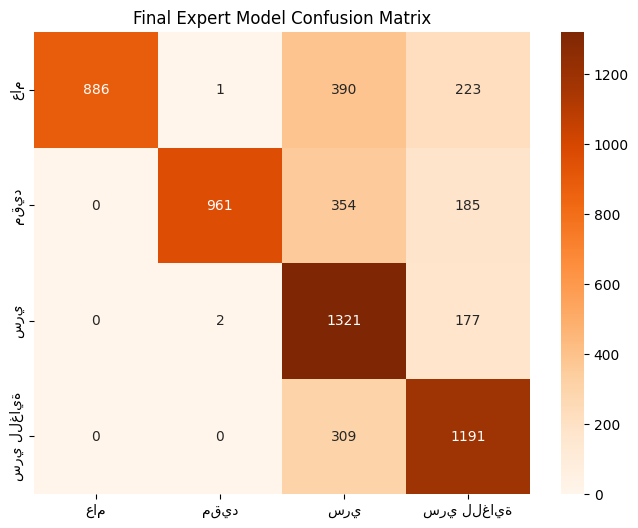

In [ ]:
# ── Classification Report & Save Results ────────────────
test_df['predicted_level'] = final_predictions
test_df.to_csv(SAVE_FILE, index=False, encoding='utf-8-sig')

print("\n" + "="*55)
print("ALLaM Fine-Tuned — Final Test Results")
print("="*55)
print(classification_report(
    test_df['sensitivity_level'], test_df['predicted_level'],
    labels=VALID_CLASSES, target_names=ENGLISH_LABELS, digits=4
))
print(f"Results saved to: {SAVE_FILE}")



🏆 FINAL EXPERT MODEL REPORT (After Fine-Tuning)
              precision    recall  f1-score   support

         عام       1.00      0.59      0.74      1500
        مقيد       1.00      0.64      0.78      1500
         سري       0.56      0.88      0.68      1500
  سري للغاية       0.67      0.79      0.73      1500

    accuracy                           0.73      6000
   macro avg       0.81      0.73      0.73      6000
weighted avg       0.81      0.73      0.73      6000



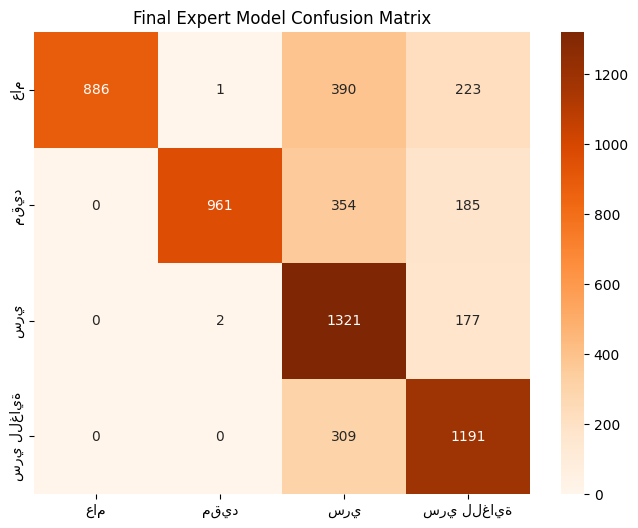

In [ ]:
# ── Confusion Matrix ─────────────────────────────────────
cm = confusion_matrix(
    test_df['sensitivity_level'], test_df['predicted_level'],
    labels=VALID_CLASSES
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=ENGLISH_LABELS, yticklabels=ENGLISH_LABELS)
plt.title('ALLaM Fine-Tuned — Confusion Matrix', fontsize=13)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.show()
